In [ ]:
import os, zipfile, warnings, json, textwrap
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 180)

RANDOM_STATE = 42
HOLDOUT_YEAR = 2025
FEATURE_VERSION = "v1.0"

BASE_DIR = Path(".")
if not (BASE_DIR / "afl_datasets").exists() and Path("/mnt/data/afl_datasets").exists():
    BASE_DIR = Path("/mnt/data")

DATA_DIR = BASE_DIR / "afl_datasets"
if not DATA_DIR.exists():
    DATA_ZIP = BASE_DIR / "afl_datasets.zip"
    if not DATA_ZIP.exists():
        try:
            from google.colab import files
            uploaded = files.upload()
            DATA_ZIP = Path(next(iter(uploaded)))
        except Exception as e:
            raise FileNotFoundError(
                "Place afl_datasets.zip beside this notebook, or upload it in Colab."
            ) from e
    with zipfile.ZipFile(DATA_ZIP) as z:
        z.extractall(BASE_DIR)
    nested = BASE_DIR / "afl_datasets" / "afl_datasets"
    if nested.exists():
        DATA_DIR = nested

OUTPUT_DIR = BASE_DIR / "week3_day2_outputs"
MODEL_DIR = OUTPUT_DIR / "models"
OUTPUT_DIR.mkdir(exist_ok=True)
MODEL_DIR.mkdir(exist_ok=True)

print("Data directory:", DATA_DIR.resolve())
print("Output directory:", OUTPUT_DIR.resolve())

Data directory: /content/afl_datasets
Output directory: /content/week3_day2_outputs


In [ ]:
def find_csv(fragment):
    matches = []
    for root, _, files in os.walk(DATA_DIR):
        for f in files:
            if fragment.lower() in f.lower() and f.lower().endswith(".csv"):
                matches.append(Path(root) / f)
    if not matches:
        raise FileNotFoundError(f"Could not find CSV containing: {fragment}")
    return matches[0]

players_info = pd.read_csv(find_csv("afl_players_info_raw.csv"), low_memory=False)
round_stats = pd.read_csv(find_csv("afl_players_round_by_round_stats_raw"), low_memory=False)
seasonal_stats = pd.read_csv(find_csv("afl_players_seasonal_stats_raw"), low_memory=False)
team_matches = pd.read_csv(find_csv("team_matches_home_away_raw"), low_memory=False)

def clean_team(s):
    return (
        s.astype(str)
         .str.replace(r"^[\t ]+|[\t ]+$", "", regex=True)
         .str.replace(r"\s+", " ", regex=True)
         .replace({"W. Bulldogs": "Western Bulldogs"})
    )

round_stats["team_clean"] = clean_team(round_stats["team"])
round_stats["opponent_clean"] = clean_team(round_stats["opponent"])
team_matches["team_clean"] = clean_team(team_matches["team_name"])
team_matches["opponent_clean"] = clean_team(team_matches["opponent"])

round_stats["match_date"] = pd.to_datetime(round_stats["match_date"], errors="coerce")
team_matches["match_date"] = pd.to_datetime(team_matches["match_date"], errors="coerce")

print({
    "players_info": players_info.shape,
    "round_stats": round_stats.shape,
    "seasonal_stats": seasonal_stats.shape,
    "team_matches": team_matches.shape,
})

{'players_info': (2848, 16), 'round_stats': (274089, 38), 'seasonal_stats': (25491, 54), 'team_matches': (15808, 21)}


In [ ]:
DAY1_FEATURE_PATHS = [
    BASE_DIR / "week3_day1_outputs" / "afl_feature_table_v1.csv",
    Path("/mnt/data/week3_day1_outputs/afl_feature_table_v1.csv"),
]

feature_path = next((p for p in DAY1_FEATURE_PATHS if p.exists()), None)

if feature_path is not None:
    feature_table_v1 = pd.read_csv(feature_path, parse_dates=["match_date"])
    print("Loaded Day 1 feature table:", feature_path)
else:
    # Rebuild the Day 1 v1.0 contract from the supplied raw data.
    tm = team_matches.drop_duplicates().copy()
    home = tm[tm.home_away.astype(str).str.upper().eq("H")].copy()

    def make_match_id(df):
        a = df.team_clean.astype(str)
        b = df.opponent_clean.astype(str)
        pair = np.where(a < b, a + "__" + b, b + "__" + a)
        return (
            df.match_date.dt.strftime("%Y-%m-%d")
            + "__" + df["round"].astype(str)
            + "__" + pair
        )

    home["match_id"] = make_match_id(home)
    home["match_result_home"] = home.result.map(
        {"W": "HOME_WIN", "L": "AWAY_WIN", "D": "DRAW"}
    )
    home["home_win_binary"] = (home.result == "W").astype(int)
    home["margin_home"] = np.select(
        [home.result.eq("W"), home.result.eq("L"), home.result.eq("D")],
        [home.margin, -home.margin, 0],
        default=np.nan,
    )

    pg = (
        round_stats.drop_duplicates()
        .sort_values(["player_id", "match_date", "id"])
        .copy()
    )
    for c in ["disposals", "goals", "fantasy_points"]:
        pg[f"prior_{c}_5"] = pg.groupby("player_id")[c].transform(
            lambda s: s.shift(1).rolling(5, min_periods=1).mean()
        )
    pg["match_id"] = make_match_id(pg)

    h = tm.sort_values(["team_clean", "match_date", "id"]).copy()
    h["win"] = (h.result == "W").astype(int)
    h["prior_win_rate_5"] = h.groupby("team_clean").win.transform(
        lambda s: s.shift(1).rolling(5, min_periods=3).mean()
    )
    h["days_rest"] = h.groupby("team_clean").match_date.diff().dt.days
    h["points"] = np.select([h.result.eq("W"), h.result.eq("D")], [4, 2], default=0)
    h["prior_ladder_points"] = h.groupby(["team_clean", "year"]).points.transform(
        lambda s: s.cumsum() - s
    )
    h["prior_pf"] = h.groupby(["team_clean", "year"]).team_score.transform(
        lambda s: s.cumsum() - s
    )
    h["prior_pa"] = h.groupby(["team_clean", "year"]).opponent_score.transform(
        lambda s: s.cumsum() - s
    )
    h["prior_ladder_pct"] = np.where(
        h.prior_pa > 0, 100 * h.prior_pf / h.prior_pa, np.nan
    )
    h["prior_ladder_rank"] = h.groupby(["year", "match_date"]).prior_ladder_points.rank(
        method="min", ascending=False
    )
    h["prior_score_avg_5"] = h.groupby("team_clean").team_score.transform(
        lambda s: s.shift(1).rolling(5, min_periods=3).mean()
    )
    h["prior_margin_avg_5"] = h.groupby("team_clean").margin.transform(
        lambda s: s.shift(1).rolling(5, min_periods=3).mean()
    )

    def calculate_prior_win_streak(s):
        out, current = [], 0
        for val in s:
            out.append(current)
            current = current + 1 if val == 1 else 0
        return pd.Series(out, index=s.index)

    h["prior_win_streak"] = h.groupby("team_clean").win.transform(
        calculate_prior_win_streak
    )
    h["match_id"] = make_match_id(h)

    h_h2h = h.sort_values(
        ["team_clean", "opponent_clean", "match_date", "id"]
    ).copy()
    h_h2h["prior_h2h_games"] = h_h2h.groupby(
        ["team_clean", "opponent_clean"]
    ).cumcount()
    h_h2h["prior_h2h_team_wins"] = h_h2h.groupby(
        ["team_clean", "opponent_clean"]
    ).win.transform(lambda s: s.shift(1).fillna(0).cumsum())

    th = h_h2h[
        [
            "match_id", "team_clean", "opponent_clean", "match_date",
            "prior_win_rate_5", "prior_score_avg_5", "prior_margin_avg_5",
            "days_rest", "prior_win_streak", "prior_ladder_points",
            "prior_ladder_pct", "prior_ladder_rank", "prior_h2h_games",
            "prior_h2h_team_wins",
        ]
    ].drop_duplicates(["match_id", "team_clean", "opponent_clean"])

    player_team_features = (
        pg.groupby(["match_id", "team_clean"])[
            ["prior_disposals_5", "prior_goals_5", "prior_fantasy_points_5"]
        ]
        .agg(["mean", "max"])
        .reset_index()
    )
    player_team_features.columns = [
        "match_id", "team_clean",
        "team_prior_player_disposals_5_mean",
        "team_prior_player_disposals_5_max",
        "team_prior_player_goals_5_mean",
        "team_prior_player_goals_5_max",
        "team_prior_player_fantasy_5_mean",
        "team_prior_player_fantasy_5_max",
    ]

    m = home[
        [
            "match_id", "year", "round", "match_date",
            "team_clean", "opponent_clean", "venue", "crowd",
            "match_result_home", "home_win_binary", "margin_home",
        ]
    ].rename(columns={"team_clean": "home_team", "opponent_clean": "away_team"})

    hf = th.rename(columns={
        "team_clean": "home_team",
        "prior_win_rate_5": "home_prior_win_rate_5",
        "prior_score_avg_5": "home_prior_score_avg_5",
        "prior_margin_avg_5": "home_prior_margin_avg_5",
        "days_rest": "home_days_rest",
        "prior_win_streak": "home_prior_win_streak",
        "prior_ladder_points": "home_prior_ladder_points",
        "prior_ladder_pct": "home_prior_ladder_pct",
        "prior_ladder_rank": "home_prior_ladder_rank",
        "prior_h2h_team_wins": "home_prior_h2h_team_wins",
        "prior_h2h_games": "home_prior_h2h_games",
    })
    af = th.rename(columns={
        "team_clean": "away_team",
        "prior_win_rate_5": "away_prior_win_rate_5",
        "prior_score_avg_5": "away_prior_score_avg_5",
        "prior_margin_avg_5": "away_prior_margin_avg_5",
        "days_rest": "away_days_rest",
        "prior_win_streak": "away_prior_win_streak",
        "prior_ladder_points": "away_prior_ladder_points",
        "prior_ladder_pct": "away_prior_ladder_pct",
        "prior_ladder_rank": "away_prior_ladder_rank",
        "prior_h2h_team_wins": "away_prior_h2h_team_wins",
        "prior_h2h_games": "away_prior_h2h_games",
    })

    hcols = [
        "home_team", "match_date", "home_prior_win_rate_5",
        "home_prior_score_avg_5", "home_prior_margin_avg_5",
        "home_days_rest", "home_prior_win_streak",
        "home_prior_ladder_points", "home_prior_ladder_pct",
        "home_prior_ladder_rank", "home_prior_h2h_team_wins",
        "home_prior_h2h_games",
    ]
    acols = [
        "away_team", "match_date", "away_prior_win_rate_5",
        "away_prior_score_avg_5", "away_prior_margin_avg_5",
        "away_days_rest", "away_prior_win_streak",
        "away_prior_ladder_points", "away_prior_ladder_pct",
        "away_prior_ladder_rank", "away_prior_h2h_team_wins",
        "away_prior_h2h_games",
    ]

    features = (
        m.merge(hf[hcols], on=["home_team", "match_date"], how="left")
         .merge(af[acols], on=["away_team", "match_date"], how="left")
    )
    features["form_diff_5"] = (
        features.home_prior_win_rate_5 - features.away_prior_win_rate_5
    )
    features["score_avg_diff_5"] = (
        features.home_prior_score_avg_5 - features.away_prior_score_avg_5
    )
    features["margin_avg_diff_5"] = (
        features.home_prior_margin_avg_5 - features.away_prior_margin_avg_5
    )
    features["rest_diff"] = features.home_days_rest - features.away_days_rest
    features["ladder_points_diff"] = (
        features.home_prior_ladder_points - features.away_prior_ladder_points
    )
    features["ladder_rank_diff"] = (
        features.away_prior_ladder_rank - features.home_prior_ladder_rank
    )

    hf2 = player_team_features.rename(columns={
        "team_clean": "home_team",
        "team_prior_player_disposals_5_mean": "home_player_disposals_5_mean",
        "team_prior_player_disposals_5_max": "home_player_disposals_5_max",
        "team_prior_player_goals_5_mean": "home_player_goals_5_mean",
        "team_prior_player_goals_5_max": "home_player_goals_5_max",
        "team_prior_player_fantasy_5_mean": "home_player_fantasy_5_mean",
        "team_prior_player_fantasy_5_max": "home_player_fantasy_5_max",
    })
    af2 = player_team_features.rename(columns={
        "team_clean": "away_team",
        "team_prior_player_disposals_5_mean": "away_player_disposals_5_mean",
        "team_prior_player_disposals_5_max": "away_player_disposals_5_max",
        "team_prior_player_goals_5_mean": "away_player_goals_5_mean",
        "team_prior_player_goals_5_max": "away_player_goals_5_max",
        "team_prior_player_fantasy_5_mean": "away_player_fantasy_5_mean",
        "team_prior_player_fantasy_5_max": "away_player_fantasy_5_max",
    })

    features = (
        features.merge(hf2, on=["match_id", "home_team"], how="left")
                .merge(af2, on=["match_id", "away_team"], how="left")
    )
    features["player_disposals_form_diff"] = (
        features.home_player_disposals_5_mean
        - features.away_player_disposals_5_mean
    )
    features["player_goals_form_diff"] = (
        features.home_player_goals_5_mean
        - features.away_player_goals_5_mean
    )
    features["player_fantasy_form_diff"] = (
        features.home_player_fantasy_5_mean
        - features.away_player_fantasy_5_mean
    )
    features["feature_version"] = FEATURE_VERSION

    feature_table_v1 = features.sort_values(
        ["match_date", "match_id"]
    ).reset_index(drop=True)

print("Feature table:", feature_table_v1.shape)
assert feature_table_v1["feature_version"].astype(str).eq(FEATURE_VERSION).all()
assert feature_table_v1["match_id"].nunique() == len(feature_table_v1)
display(feature_table_v1.head(3))

Feature table: (7904, 53)


,match_id,year,round,match_date,home_team,away_team,venue,crowd,match_result_home,home_win_binary,margin_home,home_prior_win_rate_5,home_prior_score_avg_5,home_prior_margin_avg_5,home_days_rest,home_prior_win_streak,home_prior_ladder_points,home_prior_ladder_pct,home_prior_ladder_rank,home_prior_h2h_team_wins,home_prior_h2h_games,away_prior_win_rate_5,away_prior_score_avg_5,away_prior_margin_avg_5,away_days_rest,away_prior_win_streak,away_prior_ladder_points,away_prior_ladder_pct,away_prior_ladder_rank,away_prior_h2h_team_wins,away_prior_h2h_games,form_diff_5,score_avg_diff_5,margin_avg_diff_5,rest_diff,ladder_points_diff,ladder_rank_diff,home_player_disposals_5_mean,home_player_disposals_5_max,home_player_goals_5_mean,home_player_goals_5_max,home_player_fantasy_5_mean,home_player_fantasy_5_max,away_player_disposals_5_mean,away_player_disposals_5_max,away_player_goals_5_mean,away_player_goals_5_max,away_player_fantasy_5_mean,away_player_fantasy_5_max,player_disposals_form_diff,player_goals_form_diff,player_fantasy_form_diff,feature_version
0,1983-03-26__1__Carlton Blues__Richmond Tigers,1983,1,1983-03-26,Carlton Blues,Richmond Tigers,Princes Park,28498.0,HOME_WIN,1,60.0,NaN,NaN,NaN,NaN,0,0,NaN,1.0,0.0,0,NaN,NaN,NaN,NaN,0.0,0.0,NaN,1.0,0.0,0.0,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,v1.0
1,1983-03-26__1__Collingwood Magpies__Melbourne ...,1983,1,1983-03-26,Melbourne Demons,Collingwood Magpies,Melbourne Cricket Ground,72274.0,AWAY_WIN,0,10.0,NaN,NaN,NaN,NaN,0,0,NaN,1.0,0.0,0,NaN,NaN,NaN,NaN,0.0,0.0,NaN,1.0,0.0,0.0,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,v1.0
2,1983-03-26__1__Fitzroy Lions__hawthorn hawks,1983,1,1983-03-26,Fitzroy Lions,hawthorn hawks,Junction Oval,15626.0,AWAY_WIN,0,19.0,NaN,NaN,NaN,NaN,0,0,NaN,1.0,0.0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,v1.0


## Task1: Baselines


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier, HistGradientBoostingRegressor
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    mean_absolute_error, mean_squared_error
)
from sklearn.inspection import permutation_importance
import joblib

train_match = feature_table_v1["match_date"].dt.year < HOLDOUT_YEAR
hold_match = feature_table_v1["match_date"].dt.year == HOLDOUT_YEAR

y_match = feature_table_v1["match_result_home"]

majority_class = y_match[train_match].mode().iloc[0]
majority_pred = np.repeat(majority_class, hold_match.sum())

ladder_pred = np.where(
    feature_table_v1.loc[hold_match, "home_prior_ladder_points"]
    >= feature_table_v1.loc[hold_match, "away_prior_ladder_points"],
    "HOME_WIN",
    "AWAY_WIN",
)

match_classes = np.array(["AWAY_WIN", "DRAW", "HOME_WIN"])

def multiclass_brier(y_true, probs, classes):
    one_hot = pd.get_dummies(y_true).reindex(columns=classes, fill_value=0).to_numpy()
    return float(np.mean(np.sum((one_hot - probs) ** 2, axis=1)))

def multiclass_hard_auc(y_true, pred, classes):
    probs = np.zeros((len(pred), len(classes)))
    for j, c in enumerate(classes):
        probs[:, j] = (pred == c).astype(float)
    return roc_auc_score(
        y_true, probs, multi_class="ovr", average="macro", labels=classes
    )

baseline_rows = []
for name, pred in [
    ("Majority class", majority_pred),
    ("Higher ladder points", ladder_pred),
]:
    baseline_rows.append({
        "model": name,
        "accuracy": accuracy_score(y_match[hold_match], pred),
        "macro_f1": f1_score(y_match[hold_match], pred, average="macro"),
        "roc_auc_macro_ovr": multiclass_hard_auc(y_match[hold_match], pred, match_classes),
    })

match_baseline_results = pd.DataFrame(baseline_rows)
display(match_baseline_results.round(4))

,model,accuracy,macro_f1,roc_auc_macro_ovr
0,Majority class,0.5556,0.2381,0.5000
1,Higher ladder points,0.6389,0.4266,0.5972


## Task2: Match Winner Models


In [ ]:
MATCH_FEATURES = [
    "year", "round", "venue", "home_team", "away_team",
    "home_prior_win_rate_5", "away_prior_win_rate_5",
    "home_prior_score_avg_5", "away_prior_score_avg_5",
    "home_prior_margin_avg_5", "away_prior_margin_avg_5",
    "home_days_rest", "away_days_rest",
    "home_prior_win_streak", "away_prior_win_streak",
    "home_prior_ladder_points", "away_prior_ladder_points",
    "home_prior_ladder_pct", "away_prior_ladder_pct",
    "home_prior_ladder_rank", "away_prior_ladder_rank",
    "home_prior_h2h_team_wins", "away_prior_h2h_team_wins",
    "home_prior_h2h_games", "away_prior_h2h_games",
    "form_diff_5", "score_avg_diff_5", "margin_avg_diff_5",
    "rest_diff", "ladder_points_diff", "ladder_rank_diff",
    "home_player_disposals_5_mean", "home_player_disposals_5_max",
    "home_player_goals_5_mean", "home_player_goals_5_max",
    "home_player_fantasy_5_mean", "home_player_fantasy_5_max",
    "away_player_disposals_5_mean", "away_player_disposals_5_max",
    "away_player_goals_5_mean", "away_player_goals_5_max",
    "away_player_fantasy_5_mean", "away_player_fantasy_5_max",
    "player_disposals_form_diff", "player_goals_form_diff",
    "player_fantasy_form_diff",
]

X_match = feature_table_v1[MATCH_FEATURES].copy()
Xtr_m = X_match.loc[train_match]
Xho_m = X_match.loc[hold_match]
ytr_m = y_match.loc[train_match]
yho_m = y_match.loc[hold_match]

MATCH_CAT = ["round", "venue", "home_team", "away_team"]
MATCH_NUM = [c for c in MATCH_FEATURES if c not in MATCH_CAT]

def make_match_preprocessor(scale=True):
    num_steps = [("imputer", SimpleImputer(strategy="median"))]
    if scale:
        num_steps.append(("scaler", StandardScaler()))
    return ColumnTransformer([
        ("num", Pipeline(num_steps), MATCH_NUM),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
        ]), MATCH_CAT),
    ])

match_models = {
    "Logistic Regression": Pipeline([
        ("preprocess", make_match_preprocessor(scale=True)),
        ("model", LogisticRegression(max_iter=2000, C=1.0)),
    ]),
    "Gradient Boosting": Pipeline([
        ("preprocess", make_match_preprocessor(scale=False)),
        ("model", HistGradientBoostingClassifier(
            max_iter=180,
            learning_rate=0.06,
            max_leaf_nodes=15,
            l2_regularization=1.0,
            random_state=RANDOM_STATE,
        )),
    ]),
}

match_results = []
for name, model in match_models.items():
    model.fit(Xtr_m, ytr_m)
    probs = model.predict_proba(Xho_m)
    pred = model.classes_[np.argmax(probs, axis=1)]

    match_results.append({
        "model": name,
        "accuracy": accuracy_score(yho_m, pred),
        "macro_f1": f1_score(yho_m, pred, average="macro"),
        "roc_auc_macro_ovr": roc_auc_score(
            yho_m, probs, multi_class="ovr", average="macro", labels=model.classes_
        ),
        "brier_multiclass": multiclass_brier(yho_m, probs, model.classes_),
    })

match_results_df = pd.DataFrame(match_results).sort_values(
    ["accuracy", "macro_f1", "roc_auc_macro_ovr"],
    ascending=[False, False, False],
).reset_index(drop=True)

display(match_results_df.round(4))

,model,accuracy,macro_f1,roc_auc_macro_ovr,brier_multiclass
0,Gradient Boosting,0.6528,0.4291,0.6031,0.4211
1,Logistic Regression,0.6389,0.4233,0.6356,0.4268


,probability_bin,n,mean_predicted,observed_home_win_rate
0,0.0-0.1,3,0.0625,0.0000
1,0.1-0.2,8,0.1642,0.0000
2,0.2-0.3,12,0.2548,0.1667
3,0.3-0.4,25,0.3594,0.4800
4,0.4-0.5,36,0.4553,0.4722
5,0.5-0.6,40,0.5527,0.6000
6,0.6-0.7,31,0.6548,0.5484
7,0.7-0.8,28,0.7537,0.6071
8,0.8-0.9,25,0.8472,0.9200
9,0.9-1.0,8,0.9382,1.0000


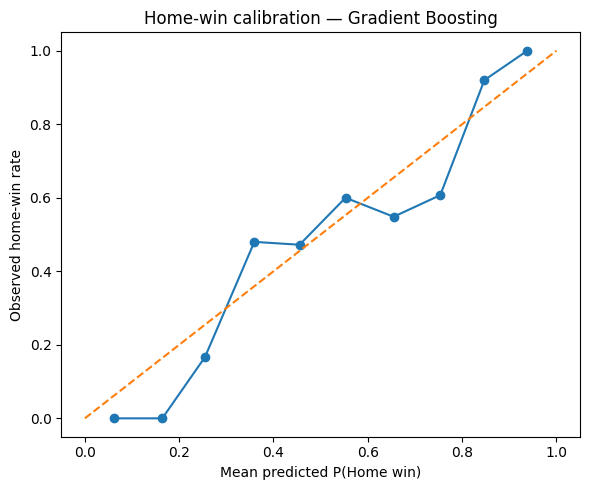

In [ ]:
# Calibration check for the probability that the home team wins
best_match_name = match_results_df.iloc[0]["model"]
best_match_model = match_models[best_match_name]
best_probs = best_match_model.predict_proba(Xho_m)
home_idx = list(best_match_model.classes_).index("HOME_WIN")
home_prob = best_probs[:, home_idx]
home_actual = (yho_m == "HOME_WIN").astype(int).to_numpy()

bins = np.linspace(0, 1, 11)
calibration_rows = []
for lo, hi in zip(bins[:-1], bins[1:]):
    mask = (home_prob >= lo) & (home_prob < hi if hi < 1 else home_prob <= hi)
    if mask.any():
        calibration_rows.append({
            "probability_bin": f"{lo:.1f}-{hi:.1f}",
            "n": int(mask.sum()),
            "mean_predicted": float(home_prob[mask].mean()),
            "observed_home_win_rate": float(home_actual[mask].mean()),
        })
calibration_df = pd.DataFrame(calibration_rows)
display(calibration_df.round(4))

plt.figure(figsize=(6, 5))
plt.plot(calibration_df["mean_predicted"], calibration_df["observed_home_win_rate"], marker="o")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("Mean predicted P(Home win)")
plt.ylabel("Observed home-win rate")
plt.title(f"Home-win calibration — {best_match_name}")
plt.tight_layout()
plt.show()

### Match model decision

The final match model is selected from the hold-out metrics rather than by assuming that the more complex model must win.

Decision rule: Prioritize hold-out accuracy, then macro F1, then ROC AUC. Use Brier score as the probability-quality tie-breaker. Gradient Boosting is preferred when it provides a meaningful predictive improvement. Logistic Regression remains the more interpretable alternative.

## Task3: Top Player Model

### Framing choice: regression + ranking

The player task is framed as regression because the supplied data contains a natural continuous performance variable: player disposals.

For each player-game:
- predictors contain only information available before that game;
- the model predicts next-match disposals;
- players are ranked by predicted disposals;
- the top-5 list is evaluated against the actual match-high disposal getter.

This is easier to explain and expose as an agent tool than a direct binary classifier because it produces a full ranked list rather than only a yes/no label.

In [ ]:
import os, zipfile, warnings, json, textwrap
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 180)

RANDOM_STATE = 42
HOLDOUT_YEAR = 2025
FEATURE_VERSION = "v1.0"

BASE_DIR = Path(".")
if not (BASE_DIR / "afl_datasets").exists() and Path("/mnt/data/afl_datasets").exists():
    BASE_DIR = Path("/mnt/data")

DATA_DIR = BASE_DIR / "afl_datasets"
if not DATA_DIR.exists():
    DATA_ZIP = BASE_DIR / "afl_datasets.zip"
    if not DATA_ZIP.exists():
        try:
            from google.colab import files
            uploaded = files.upload()
            DATA_ZIP = Path(next(iter(uploaded)))
        except Exception as e:
            raise FileNotFoundError(
                "Place afl_datasets.zip beside this notebook, or upload it in Colab."
            ) from e
    with zipfile.ZipFile(DATA_ZIP) as z:
        z.extractall(BASE_DIR)
    nested = BASE_DIR / "afl_datasets" / "afl_datasets"
    if nested.exists():
        DATA_DIR = nested

OUTPUT_DIR = BASE_DIR / "week3_day2_outputs"
MODEL_DIR = OUTPUT_DIR / "models"
OUTPUT_DIR.mkdir(exist_ok=True)
MODEL_DIR.mkdir(exist_ok=True)

print("Data directory:", DATA_DIR.resolve())
print("Output directory:", OUTPUT_DIR.resolve())

def find_csv(fragment):
    matches = []
    for root, _, files in os.walk(DATA_DIR):
        for f in files:
            if fragment.lower() in f.lower() and f.lower().endswith(".csv"):
                matches.append(Path(root) / f)
    if not matches:
        raise FileNotFoundError(f"Could not find CSV containing: {fragment}")
    return matches[0]

players_info = pd.read_csv(find_csv("afl_players_info_raw.csv"), low_memory=False)
round_stats = pd.read_csv(find_csv("afl_players_round_by_round_stats_raw"), low_memory=False)
seasonal_stats = pd.read_csv(find_csv("afl_players_seasonal_stats_raw"), low_memory=False)
team_matches = pd.read_csv(find_csv("team_matches_home_away_raw"), low_memory=False)

def clean_team(s):
    return (
        s.astype(str)
         .str.replace(r"^[\t ]+|[\t ]+$", "", regex=True)
         .str.replace(r"\s+", " ", regex=True)
         .replace({"W. Bulldogs": "Western Bulldogs"})
    )

round_stats["team_clean"] = clean_team(round_stats["team"])
round_stats["opponent_clean"] = clean_team(round_stats["opponent"])
team_matches["team_clean"] = clean_team(team_matches["team_name"])
team_matches["opponent_clean"] = clean_team(team_matches["opponent"])

round_stats["match_date"] = pd.to_datetime(round_stats["match_date"], errors="coerce")
team_matches["match_date"] = pd.to_datetime(team_matches["match_date"], errors="coerce")

print({
    "players_info": players_info.shape,
    "round_stats": round_stats.shape,
    "seasonal_stats": seasonal_stats.shape,
    "team_matches": team_matches.shape,
})

def make_match_id(df):
    a = df.team_clean.astype(str)
    b = df.opponent_clean.astype(str)
    pair = np.where(a < b, a + "__" + b, b + "__" + a)
    return (
        df.match_date.dt.strftime("%Y-%m-%d")
        + "__" + df["round"].astype(str)
        + "__" + pair
    )

# Building player-level leakage-safe context
player_model_df = (
    round_stats.drop_duplicates()
    .sort_values(["player_id", "match_date", "id"])
    .copy()
)

player_model_df["match_id"] = make_match_id(player_model_df)

for c in ["disposals", "goals", "fantasy_points"]:
    player_model_df[f"prior_{c}_5"] = player_model_df.groupby("player_id")[c].transform(
        lambda s: s.shift(1).rolling(5, min_periods=1).mean()
    )

player_model_df["prior_disposals_last"] = (
    player_model_df.groupby("player_id")["disposals"].shift(1)
)

prior_sum = player_model_df.groupby("player_id")["disposals"].transform(
    lambda s: s.shift(1).cumsum()
)
prior_n = player_model_df.groupby("player_id")["disposals"].transform(
    lambda s: s.shift(1).notna().cumsum()
)
player_model_df["prior_career_disposals_avg"] = np.where(
    prior_n > 0, prior_sum / prior_n, np.nan
)

# Only games earlier in the same season are used
season_prior_sum = player_model_df.groupby(
    ["player_id", "year"]
)["disposals"].transform(lambda s: s.shift(1).cumsum())
season_prior_n = player_model_df.groupby(
    ["player_id", "year"]
)["disposals"].transform(lambda s: s.shift(1).notna().cumsum())
player_model_df["prior_season_disposals_avg"] = np.where(
    season_prior_n > 0, season_prior_sum / season_prior_n, np.nan
)

player_model_df["prior_games_count"] = player_model_df.groupby("player_id").cumcount()
player_model_df["target_disposals"] = player_model_df["disposals"]

# Ensuring home_team and away_team are kept
match_context_for_players_cols = [
    "match_id", "home_team", "away_team"
] + [
    c for c in MATCH_FEATURES if c not in {"home_team", "away_team"}
]
match_context_for_players = feature_table_v1[match_context_for_players_cols].drop_duplicates("match_id")

player_model_df = player_model_df.merge(
    match_context_for_players,
    on="match_id",
    how="left",
    suffixes=('', '_match')
)

player_model_df["is_home_player"] = (
    player_model_df["team_clean"] == player_model_df["home_team"]
).astype(int)

player_model_df = player_model_df[player_model_df["target_disposals"].notna()].copy()

PLAYER_FEATURES = [
    "team_clean", "opponent_clean", "round", "venue", "is_home_player",
    "prior_disposals_5", "prior_disposals_last",
    "prior_career_disposals_avg", "prior_games_count",
    "prior_goals_5", "prior_fantasy_points_5",
] + [
    c for c in MATCH_FEATURES
    if c not in {"home_team", "away_team", "round", "venue", "year"}
]

PLAYER_FEATURES = list(dict.fromkeys(PLAYER_FEATURES))
PLAYER_CAT = [c for c in PLAYER_FEATURES if player_model_df[c].dtype == "object"]
PLAYER_NUM = [c for c in PLAYER_FEATURES if c not in PLAYER_CAT]

train_player = player_model_df["match_date"].dt.year < HOLDOUT_YEAR
hold_player = player_model_df["match_date"].dt.year == HOLDOUT_YEAR

Xtr_p = player_model_df.loc[train_player, PLAYER_FEATURES]
Xho_p = player_model_df.loc[hold_player, PLAYER_FEATURES]
ytr_p = player_model_df.loc[train_player, "target_disposals"]
yho_p = player_model_df.loc[hold_player, "target_disposals"]

player_pre = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
    ]), PLAYER_NUM),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ]), PLAYER_CAT),
])

top_player_model = Pipeline([
    ("preprocess", player_pre),
    ("model", HistGradientBoostingRegressor(
        max_iter=120,
        learning_rate=0.08,
        max_leaf_nodes=31,
        l2_regularization=2.0,
        random_state=RANDOM_STATE,
    )),
])

top_player_model.fit(Xtr_p, ytr_p)
player_pred = top_player_model.predict(Xho_p)

print("Hold-out player rows:", len(yho_p))
print("Hold-out matches:", player_model_df.loc[hold_player, "match_id"].nunique())

Data directory: /content/afl_datasets
Output directory: /content/week3_day2_outputs
{'players_info': (2848, 16), 'round_stats': (274089, 38), 'seasonal_stats': (25491, 54), 'team_matches': (15808, 21)}
Hold-out player rows: 9619
Hold-out matches: 216


In [ ]:
# Top-5 hit-rate evaluator.
hold_player_eval = player_model_df.loc[
    hold_player,
    ["match_id", "player_id", "target_disposals",
     "prior_disposals_last", "prior_season_disposals_avg"]
].copy()
hold_player_eval["model_pred"] = player_pred

def top5_hit_rate(df, score_col, k=5):
    hits = []
    for _, g in df.groupby("match_id"):
        predicted = set(g.nlargest(k, score_col)["player_id"])
        actual_max = g["target_disposals"].max()
        actual = set(g.loc[g["target_disposals"] == actual_max, "player_id"])
        hits.append(bool(predicted & actual))
    return float(np.mean(hits))

top_player_results = pd.DataFrame([
    {
        "model": "Last-match leader baseline",
        "MAE": np.nan,
        "RMSE": np.nan,
        "top5_hit_rate": top5_hit_rate(
            hold_player_eval, "prior_disposals_last"
        ),
    },
    {
        "model": "Season-to-date average baseline",
        "MAE": np.nan,
        "RMSE": np.nan,
        "top5_hit_rate": top5_hit_rate(
            hold_player_eval, "prior_season_disposals_avg"
        ),
    },
    {
        "model": "Gradient Boosting regressor",
        "MAE": mean_absolute_error(yho_p, player_pred),
        "RMSE": mean_squared_error(yho_p, player_pred) ** 0.5,
        "top5_hit_rate": top5_hit_rate(
            hold_player_eval, "model_pred"
        ),
    },
])

display(top_player_results.round(4))


,model,MAE,RMSE,top5_hit_rate
0,Last-match leader baseline,NaN,NaN,0.5417
1,Season-to-date average baseline,NaN,NaN,0.6806
2,Gradient Boosting regressor,3.8971,5.0034,0.7269


## Task4: Feature Importance & Sanity Checks

Two views are used:
- Logistic Regression coefficients for directional interpretability
- Permutation importance on the hold-out sample for the nonlinear models

The checks should answer:
- Are recent form, ladder strength, rest and matchup history important?
- Are any suspicious current-match fields accidentally included?
- Does the model behave sensibly on a few held-out matches?

In [ ]:
# Logistic Regression coefficient importance by transformed feature
logit = match_models["Logistic Regression"]
logit_pre = logit.named_steps["preprocess"]
logit_model = logit.named_steps["model"]

feature_names = logit_pre.get_feature_names_out()
coef_abs = np.mean(np.abs(logit_model.coef_), axis=0)

logit_importance = (
    pd.DataFrame({"transformed_feature": feature_names, "mean_abs_coefficient": coef_abs})
    .sort_values("mean_abs_coefficient", ascending=False)
    .head(20)
)
display(logit_importance.round(4))

,transformed_feature,mean_abs_coefficient
171,cat__away_team_brisbane lions,0.6406
183,cat__away_team_port adelaide power,0.5369
57,cat__round_22,0.5321
178,cat__away_team_gold coast suns,0.4860
71,cat__round_SF,0.4633
180,cat__away_team_hawthorn hawks,0.4604
158,cat__away_team_Gold Coast Suns,0.4439
147,cat__home_team_West Coast Eagles,0.4368
58,cat__round_23,0.4315
107,cat__venue_Princes Park\n,0.4307


In [ ]:
# Permutation importance for the final match model on a reproducible hold-out sample
sample_n = min(1000, len(Xho_m))
sample_idx = Xho_m.sample(sample_n, random_state=RANDOM_STATE).index

perm_match = permutation_importance(
    best_match_model,
    Xho_m.loc[sample_idx],
    yho_m.loc[sample_idx],
    scoring="accuracy",
    n_repeats=5,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

match_perm = (
    pd.DataFrame({
        "feature": MATCH_FEATURES,
        "importance_mean": perm_match.importances_mean,
        "importance_std": perm_match.importances_std,
    })
    .sort_values("importance_mean", ascending=False)
)
display(match_perm.head(15).round(4))

,feature,importance_mean,importance_std
17,home_prior_ladder_pct,0.0333,0.0210
23,home_prior_h2h_games,0.0278,0.0113
29,ladder_points_diff,0.0176,0.0090
31,home_player_disposals_5_mean,0.0167,0.0023
35,home_player_fantasy_5_mean,0.0157,0.0047
18,away_prior_ladder_pct,0.0157,0.0133
4,away_team,0.0120,0.0126
38,away_player_disposals_5_max,0.0102,0.0019
33,home_player_goals_5_mean,0.0102,0.0054
25,form_diff_5,0.0083,0.0054


In [ ]:
# Permutation importance for the top-player regressor
sample_n = min(5000, len(Xho_p))
sample_idx = Xho_p.sample(sample_n, random_state=RANDOM_STATE).index

perm_player = permutation_importance(
    top_player_model,
    Xho_p.loc[sample_idx],
    yho_p.loc[sample_idx],
    scoring="neg_mean_absolute_error",
    n_repeats=3,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

player_perm = (
    pd.DataFrame({
        "feature": PLAYER_FEATURES,
        "importance_mean_neg_mae": perm_player.importances_mean,
        "importance_std": perm_player.importances_std,
    })
    .sort_values("importance_mean_neg_mae", ascending=False)
)
display(player_perm.head(15).round(4))

,feature,importance_mean_neg_mae,importance_std
5,prior_disposals_5,1.8692,0.0549
7,prior_career_disposals_avg,0.3357,0.0104
6,prior_disposals_last,0.0908,0.0082
8,prior_games_count,0.0595,0.0018
4,is_home_player,0.0123,0.0017
9,prior_goals_5,0.0063,0.0024
1,opponent_clean,0.0048,0.0013
15,home_prior_margin_avg_5,0.0047,0.0005
16,away_prior_margin_avg_5,0.0045,0.0006
2,round,0.0024,0.0008


In [ ]:
# Explicit leakage audit
FORBIDDEN_MATCH_FEATURES = {
    "match_id", "match_result_home", "home_win_binary", "margin_home",
    "crowd", "home_score", "away_score", "team_score", "opponent_score",
    "goals", "disposals", "fantasy_points", "top_disposal_getter",
    "top_goal_kicker",
}

print("Forbidden columns accidentally used by match model:",
      sorted(set(MATCH_FEATURES) & FORBIDDEN_MATCH_FEATURES))

FORBIDDEN_PLAYER_FEATURES = {
    "target_disposals", "disposals", "goals", "fantasy_points",
    "match_result_home", "home_win_binary", "margin_home",
}

print("Forbidden columns accidentally used by player model:",
      sorted(set(PLAYER_FEATURES) & FORBIDDEN_PLAYER_FEATURES))

assert not (set(MATCH_FEATURES) & FORBIDDEN_MATCH_FEATURES)
assert not (set(PLAYER_FEATURES) & FORBIDDEN_PLAYER_FEATURES)
print("Leakage audit passed.")

Forbidden columns accidentally used by match model: []
Forbidden columns accidentally used by player model: []
Leakage audit passed.


### Sniff test:

The table below selects three deterministic 2025 matches. For each one, the notebook records:
- a simple football-style expectation from recent form and ladder strength;
- the model prediction and probability
- the actual result
- a short written analyst note explaining the pre-match reasoning.



In [ ]:
sniff = (
    feature_table_v1.loc[hold_match, [
        "match_id", "match_date", "home_team", "away_team",
        "match_result_home",
        "form_diff_5", "ladder_points_diff", "rest_diff",
    ]]
    .sort_values("match_date")
    .sample(3, random_state=RANDOM_STATE)
    .sort_values("match_date")
    .copy()
)

# Using the indices from the sampled 'sniff' DataFrame to select all 'MATCH_FEATURES' from 'feature_table_v1'
sniff_X = feature_table_v1.loc[sniff.index, MATCH_FEATURES]
sniff_probs = best_match_model.predict_proba(sniff_X)
sniff_pred = best_match_model.classes_[np.argmax(sniff_probs, axis=1)]

def heuristic(row):
    score = 0
    if pd.notna(row["form_diff_5"]):
        score += np.sign(row["form_diff_5"])
    if pd.notna(row["ladder_points_diff"]):
        score += np.sign(row["ladder_points_diff"])
    return "HOME_WIN" if score >= 0 else "AWAY_WIN"

sniff["football_expectation"] = sniff.apply(heuristic, axis=1)
sniff["model_prediction"] = sniff_pred
sniff["model_probability"] = [
    float(np.max(p)) for p in sniff_probs
]
sniff["actual_result"] = sniff["match_result_home"]
sniff["model_vs_expectation"] = np.where(
    sniff["model_prediction"] == sniff["football_expectation"],
    "AGREE", "DISAGREE"
)

def written_reasoning(row):
    form = row["form_diff_5"]
    ladder = row["ladder_points_diff"]

    if pd.notna(form) and form > 0:
        form_text = "the home side had the stronger recent five-game win rate"
    elif pd.notna(form) and form < 0:
        form_text = "the away side had the stronger recent five-game win rate"
    else:
        form_text = "recent five-game form was broadly even or unavailable"

    if pd.notna(ladder) and ladder > 0:
        ladder_text = "the home side also had the stronger pre-match ladder points"
    elif pd.notna(ladder) and ladder < 0:
        ladder_text = "the away side also had the stronger pre-match ladder points"
    else:
        ladder_text = "pre-match ladder points were broadly even or unavailable"

    return f"Pre-match, I would lean toward {row['football_expectation']} because {form_text}, while {ladder_text}. The model predicts {row['model_prediction']} at {row['model_probability']:.1%}."

sniff["written_analyst_reasoning"] = sniff.apply(written_reasoning, axis=1)

display(sniff[[
    "match_date", "home_team", "away_team",
    "form_diff_5", "ladder_points_diff", "rest_diff",
    "football_expectation", "model_prediction",
    "model_probability", "actual_result",
    "model_vs_expectation", "written_analyst_reasoning"
]].round(4))

,match_date,home_team,away_team,form_diff_5,ladder_points_diff,...,model_prediction,model_probability,actual_result,model_vs_expectation,written_analyst_reasoning
7826,2025-07-05,Essendon Bombers,gold coast suns,NaN,NaN,...,HOME_WIN,0.6825,AWAY_WIN,AGREE,"Pre-match, I would lean toward HOME_WIN becaus..."
7889,2025-08-23,Richmond Tigers,Geelong Cats,-0.8,-44.0,...,AWAY_WIN,0.9456,AWAY_WIN,AGREE,"Pre-match, I would lean toward AWAY_WIN becaus..."
7901,2025-09-19,Geelong Cats,Hawthorn Hawks,0.2,4.0,...,HOME_WIN,0.5490,HOME_WIN,AGREE,"Pre-match, I would lean toward HOME_WIN becaus..."


In [ ]:
# Final baseline-vs-model summary
match_summary = pd.concat([
    match_baseline_results[[
        "model", "accuracy", "macro_f1", "roc_auc_macro_ovr"
    ]],
    match_results_df[[
        "model", "accuracy", "macro_f1", "roc_auc_macro_ovr"
    ]],
], ignore_index=True)

player_summary = top_player_results[[
    "model", "top5_hit_rate", "MAE", "RMSE"
]].copy()

print("Match winner — baseline vs trained models")
display(match_summary.round(4))

print("Top player — baseline vs trained model")
display(player_summary.round(4))


Match winner — baseline vs trained models


,model,accuracy,macro_f1,roc_auc_macro_ovr
0,Majority class,0.5556,0.2381,0.5000
1,Higher ladder points,0.6389,0.4266,0.5972
2,Gradient Boosting,0.6528,0.4291,0.6031
3,Logistic Regression,0.6389,0.4233,0.6356


Top player — baseline vs trained model


,model,top5_hit_rate,MAE,RMSE
0,Last-match leader baseline,0.5417,NaN,NaN
1,Season-to-date average baseline,0.6806,NaN,NaN
2,Gradient Boosting regressor,0.7269,3.8971,5.0034


## 6. Final model selection and packaging

The selected match model is the best hold-out classifier under the documented decision rule.

The selected player model is the Gradient Boosting regressor because the task is ranking-by-predicted-disposals; its key success measure is top-5 hit rate, with MAE/RMSE providing the regression quality check.

The final baseline-vs-model summary above provides the direct comparison required by the assignment.

The following cell:
- saves both complete sklearn pipelines with `joblib`;
- saves the feature lists and model metadata;
- saves hold-out evaluation tables;
- saves match/player context histories needed by the callable prediction functions;
- writes a ready-to-use `predict.py`.


In [ ]:
PREDICT_PY = r'''
from pathlib import Path
from datetime import datetime
import json
import joblib
import numpy as np
import pandas as pd

HERE = Path(__file__).resolve().parent
MODEL_DIR = HERE / "models"

MATCH_MODEL_PATH = MODEL_DIR / "match_winner_model.joblib"
PLAYER_MODEL_PATH = MODEL_DIR / "top_player_model.joblib"
METADATA_PATH = MODEL_DIR / "model_metadata.json"
MATCH_CONTEXT_PATH = MODEL_DIR / "match_context.csv"
TEAM_CONTEXT_PATH = MODEL_DIR / "team_context_history.csv"
PLAYER_CONTEXT_PATH = MODEL_DIR / "player_context_history.csv"

class AFLPredictionError(ValueError):
    pass

def _load():
    for p in [MATCH_MODEL_PATH, PLAYER_MODEL_PATH, METADATA_PATH,
              MATCH_CONTEXT_PATH, TEAM_CONTEXT_PATH, PLAYER_CONTEXT_PATH]:
        if not p.exists():
            raise FileNotFoundError(
                f"Required model/context file is missing: {p}. "
                "Run the Week 3 Day 2 notebook packaging cell first."
            )
    return (
        joblib.load(MATCH_MODEL_PATH),
        joblib.load(PLAYER_MODEL_PATH),
        json.loads(METADATA_PATH.read_text()),
        pd.read_csv(MATCH_CONTEXT_PATH, parse_dates=["match_date"]),
        pd.read_csv(TEAM_CONTEXT_PATH, parse_dates=["last_match_date"]),
        pd.read_csv(PLAYER_CONTEXT_PATH, parse_dates=["match_date"]),
    )

def _validate_date(date):
    try:
        parsed = pd.Timestamp(date)
    except Exception as exc:
        raise AFLPredictionError(
            f"Invalid date '{date}'. Use YYYY-MM-DD."
        ) from exc

    if pd.isna(parsed):
        raise AFLPredictionError(
            f"Invalid date '{date}'. Use YYYY-MM-DD."
        )

    return parsed.normalize()

def _validate_teams(team_a, team_b, team_context):
    teams = set(team_context["team_clean"].dropna().astype(str))
    if team_a not in teams:
        raise AFLPredictionError(
            f"Unknown team '{team_a}'. Check the normalized AFL team name."
        )
    if team_b not in teams:
        raise AFLPredictionError(
            f"Unknown team '{team_b}'. Check the normalized AFL team name."
        )
    if team_a == team_b:
        raise AFLPredictionError("team_a and team_b must be different teams.")

def _latest_team_row(team, date, team_context):
    rows = team_context[
        (team_context["team_clean"] == team)
        & (team_context["last_match_date"] < date)
    ].sort_values("last_match_date")
    if rows.empty:
        raise AFLPredictionError(
            f"No historical context exists for '{team}' before {date.date()}."
        )
    return rows.iloc[-1]

def _build_future_match_row(team_a, team_b, date, match_context, team_context):
    exact = match_context[
        (match_context["match_date"] == date)
        & (match_context["home_team"] == team_a)
        & (match_context["away_team"] == team_b)
    ]
    if not exact.empty:
        return exact.iloc[0].to_dict()

    h = _latest_team_row(team_a, date, team_context)
    a = _latest_team_row(team_b, date, team_context)

    row = {
        "year": date.year,
        "round": "UNKNOWN",
        "venue": "UNKNOWN",
        "home_team": team_a,
        "away_team": team_b,
        "home_prior_win_rate_5": h["prior_win_rate_5"],
        "away_prior_win_rate_5": a["prior_win_rate_5"],
        "home_prior_score_avg_5": h["prior_score_avg_5"],
        "away_prior_score_avg_5": a["prior_score_avg_5"],
        "home_prior_margin_avg_5": h["prior_margin_avg_5"],
        "away_prior_margin_avg_5": a["prior_margin_avg_5"],
        "home_days_rest": (date - pd.Timestamp(h["last_match_date"])).days,
        "away_days_rest": (date - pd.Timestamp(a["last_match_date"])).days,
        "home_prior_win_streak": h["prior_win_streak"],
        "away_prior_win_streak": a["prior_win_streak"],
        "home_prior_ladder_points": h["prior_ladder_points"],
        "away_prior_ladder_points": a["prior_ladder_points"],
        "home_prior_ladder_pct": h["prior_ladder_pct"],
        "away_prior_ladder_pct": a["prior_ladder_pct"],
        "home_prior_ladder_rank": h["prior_ladder_rank"],
        "away_prior_ladder_rank": a["prior_ladder_rank"],
        "home_prior_h2h_team_wins": 0,
        "away_prior_h2h_team_wins": 0,
        "home_prior_h2h_games": 0,
        "away_prior_h2h_games": 0,
        "home_player_disposals_5_mean": np.nan,
        "home_player_disposals_5_max": np.nan,
        "home_player_goals_5_mean": np.nan,
        "home_player_goals_5_max": np.nan,
        "home_player_fantasy_5_mean": np.nan,
        "home_player_fantasy_5_max": np.nan,
        "away_player_disposals_5_mean": np.nan,
        "away_player_disposals_5_max": np.nan,
        "away_player_goals_5_mean": np.nan,
        "away_player_goals_5_max": np.nan,
        "away_player_fantasy_5_mean": np.nan,
        "away_player_fantasy_5_max": np.nan,
    }

    row["form_diff_5"] = row["home_prior_win_rate_5"] - row["away_prior_win_rate_5"]
    row["score_avg_diff_5"] = row["home_prior_score_avg_5"] - row["away_prior_score_avg_5"]
    row["margin_avg_diff_5"] = row["home_prior_margin_avg_5"] - row["away_prior_margin_avg_5"]
    row["rest_diff"] = row["home_days_rest"] - row["away_days_rest"]
    row["ladder_points_diff"] = row["home_prior_ladder_points"] - row["away_prior_ladder_points"]
    row["ladder_rank_diff"] = row["away_prior_ladder_rank"] - row["home_prior_ladder_rank"]
    row["player_disposals_form_diff"] = np.nan
    row["player_goals_form_diff"] = np.nan
    row["player_fantasy_form_diff"] = np.nan
    return row

def predict_match_winner(team_a, team_b, date):
    """Predict team_a as home vs team_b as away.

    Returns a dict with the predicted winner, class probabilities,
    and the model's confidence. For dates not already in the historical
    match table, the function uses the latest pre-date team context.
    """
    match_model, _, metadata, match_context, team_context, _ = _load()
    date = _validate_date(date)
    _validate_teams(team_a, team_b, team_context)

    row = _build_future_match_row(
        team_a, team_b, date, match_context, team_context
    )
    cols = metadata["match_features"]
    X = pd.DataFrame([row])[cols]

    probs = match_model.predict_proba(X)[0]
    classes = list(match_model.classes_)
    best_idx = int(np.argmax(probs))

    return {
        "winner": classes[best_idx],
        "probability": float(probs[best_idx]),
        "probabilities": {
            cls: float(prob) for cls, prob in zip(classes, probs)
        },
        "team_a": team_a,
        "team_b": team_b,
        "date": str(date.date()),
    }

def predict_top_player(
    team_a,
    team_b,
    date,
    stat_type="disposals",
    top_k=5,
    candidate_player_ids=None,
):
    """Rank likely top players for the upcoming team_a vs team_b match.

    The trained model predicts next-match disposals. Candidate players can
    be supplied explicitly; otherwise the latest pre-date player contexts
    for both teams are used. Explicit candidates are recommended when
    confirmed line-ups are available.
    """
    if stat_type != "disposals":
        raise AFLPredictionError(
            "This Week 3 model currently supports stat_type='disposals' only."
        )
    if not isinstance(top_k, int) or top_k < 1:
        raise AFLPredictionError("top_k must be a positive integer.")

    match_model, player_model, metadata, match_context, team_context, player_context = _load()
    date = _validate_date(date)
    _validate_teams(team_a, team_b, team_context)

    match_row = _build_future_match_row(
        team_a, team_b, date, match_context, team_context
    )

    pc = player_context[
        (player_context["match_date"] < date)
        & (player_context["team_clean"].isin([team_a, team_b]))
    ].sort_values("match_date")

    if candidate_player_ids is not None:
        ids = set(candidate_player_ids)
        known_ids = set(player_context["player_id"].dropna().astype(int))
        unknown_ids = sorted(int(pid) for pid in ids if int(pid) not in known_ids)
        if unknown_ids:
            raise AFLPredictionError(
                f"Unknown player_id(s): {unknown_ids}."
            )

        pc = pc[pc["player_id"].isin(ids)]
        if pc.empty:
            raise AFLPredictionError(
                "The supplied player_id(s) are known, but none has usable "
                f"pre-date historical context before {date.date()}."
            )

    latest = pc.groupby("player_id", as_index=False).tail(1).copy()
    latest["home_team"] = team_a
    latest["away_team"] = team_b
    latest["year"] = date.year
    latest["round"] = "UNKNOWN"
    latest["venue"] = "UNKNOWN"
    latest["is_home_player"] = (latest["team_clean"] == team_a).astype(int)

    for c in [
        "home_prior_win_rate_5", "away_prior_win_rate_5",
        "home_prior_score_avg_5", "away_prior_score_avg_5",
        "home_prior_margin_avg_5", "away_prior_margin_avg_5",
        "home_days_rest", "away_days_rest",
        "home_prior_win_streak", "away_prior_win_streak",
        "home_prior_ladder_points", "away_prior_ladder_points",
        "home_prior_ladder_pct", "away_prior_ladder_pct",
        "home_prior_ladder_rank", "away_prior_ladder_rank",
        "home_prior_h2h_team_wins", "away_prior_h2h_team_wins",
        "home_prior_h2h_games", "away_prior_h2h_games",
        "form_diff_5", "score_avg_diff_5", "margin_avg_diff_5",
        "rest_diff", "ladder_points_diff", "ladder_rank_diff",
        "home_player_disposals_5_mean", "home_player_disposals_5_max",
        "home_player_goals_5_mean", "home_player_goals_5_max",
        "home_player_fantasy_5_mean", "home_player_fantasy_5_max",
        "away_player_disposals_5_mean", "away_player_disposals_5_max",
        "away_player_goals_5_mean", "away_player_goals_5_max",
        "away_player_fantasy_5_mean", "away_player_fantasy_5_max",
        "player_disposals_form_diff", "player_goals_form_diff",
        "player_fantasy_form_diff",
    ]:
        latest[c] = match_row.get(c, np.nan)

    # Preserve player-specific team/form columns after assigning match context.
    # The model needs these values from each player's prior context.
    feature_cols = metadata["player_features"]
    X = latest[feature_cols]
    latest["predicted_disposals"] = player_model.predict(X)

    latest = latest.sort_values(
        "predicted_disposals", ascending=False
    ).head(top_k)

    name_map = {}
    if "player_name" in latest.columns:
        name_map = latest.set_index("player_id")["player_name"].to_dict()

    results = []
    for _, r in latest.iterrows():
        results.append({
            "player_id": int(r["player_id"]),
            "player_name": name_map.get(r["player_id"]),
            "team": r["team_clean"],
            "predicted_disposals": float(r["predicted_disposals"]),
        })

    return results
'''
(OUTPUT_DIR / "predict.py").write_text(PREDICT_PY, encoding="utf-8")
print("Wrote:", OUTPUT_DIR / "predict.py")

Wrote: week3_day2_outputs/predict.py


In [ ]:
# Save context histories used by predict.py.
# Build team context directly from the Day 1 feature table so this works
# whether the table was loaded from disk or rebuilt above.

home_context = feature_table_v1[
    [
        "home_team", "match_date",
        "home_prior_win_rate_5", "home_prior_score_avg_5",
        "home_prior_margin_avg_5", "home_days_rest",
        "home_prior_win_streak", "home_prior_ladder_points",
        "home_prior_ladder_pct", "home_prior_ladder_rank",
    ]
].copy()
home_context.columns = [
    "team_clean", "last_match_date",
    "prior_win_rate_5", "prior_score_avg_5",
    "prior_margin_avg_5", "days_rest",
    "prior_win_streak", "prior_ladder_points",
    "prior_ladder_pct", "prior_ladder_rank",
]

away_context = feature_table_v1[
    [
        "away_team", "match_date",
        "away_prior_win_rate_5", "away_prior_score_avg_5",
        "away_prior_margin_avg_5", "away_days_rest",
        "away_prior_win_streak", "away_prior_ladder_points",
        "away_prior_ladder_pct", "away_prior_ladder_rank",
    ]
].copy()
away_context.columns = home_context.columns

team_context_history = pd.concat(
    [home_context, away_context], ignore_index=True
).sort_values(["team_clean", "last_match_date"])

# Player history contains only pre-match player form.
player_context_history = player_model_df[
    [
        "player_id", "team_clean", "opponent_clean", "match_date",
        "prior_disposals_5", "prior_disposals_last",
        "prior_career_disposals_avg", "prior_games_count",
        "prior_goals_5", "prior_fantasy_points_5",
    ]
].copy()

# Include names where available.
names = players_info[["id", "player_name"]].drop_duplicates("id").copy()
names["player_id"] = pd.to_numeric(names["id"], errors="coerce")
player_context_history = player_context_history.merge(
    names[["player_id", "player_name"]],
    on="player_id",
    how="left",
)

match_context = feature_table_v1.copy()

team_context_history.to_csv(MODEL_DIR / "team_context_history.csv", index=False)
player_context_history.to_csv(MODEL_DIR / "player_context_history.csv", index=False)
match_context.to_csv(MODEL_DIR / "match_context.csv", index=False)

print("Saved context histories.")

Saved context histories.


In [ ]:
joblib.dump(best_match_model, MODEL_DIR / "match_winner_model.joblib")
joblib.dump(top_player_model, MODEL_DIR / "top_player_model.joblib")

metadata = {
    "feature_version": FEATURE_VERSION,
    "holdout_year": HOLDOUT_YEAR,
    "match_model_name": best_match_name,
    "match_features": MATCH_FEATURES,
    "player_features": PLAYER_FEATURES,
    "player_target": "next_match_disposals",
    "top_k_metric": "top-5 hit rate",
    "notes": [
        "Time split: train seasons before 2025, hold out 2025.",
        "Current-match result/performance fields are excluded from predictors.",
        "Top-player framing is regression followed by ranking.",
        "Future match predictions use latest pre-date team context when an exact historical match row is unavailable.",
        "Future player predictions should receive confirmed candidate_player_ids when available.",
    ],
}
(MODEL_DIR / "model_metadata.json").write_text(
    json.dumps(metadata, indent=2),
    encoding="utf-8",
)

match_results_df.to_csv(OUTPUT_DIR / "match_model_evaluation.csv", index=False)
match_baseline_results.to_csv(OUTPUT_DIR / "match_baseline_evaluation.csv", index=False)
top_player_results.to_csv(OUTPUT_DIR / "top_player_evaluation.csv", index=False)
match_perm.to_csv(OUTPUT_DIR / "match_feature_permutation_importance.csv", index=False)
player_perm.to_csv(OUTPUT_DIR / "player_feature_permutation_importance.csv", index=False)
logit_importance.to_csv(OUTPUT_DIR / "logistic_coefficient_importance.csv", index=False)
calibration_df.to_csv(OUTPUT_DIR / "match_calibration.csv", index=False)
sniff.to_csv(OUTPUT_DIR / "sniff_test_2025.csv", index=False)

print("Saved model artifacts:")
for p in sorted(MODEL_DIR.iterdir()):
    print(" -", p.name)

Saved model artifacts:
 - match_context.csv
 - match_winner_model.joblib
 - model_metadata.json
 - player_context_history.csv
 - team_context_history.csv
 - top_player_model.joblib


## Final interpretation

### Match winner:
Use the final baseline-vs-model table to compare both trained classifiers with the two simple baselines. The final model is selected under the documented accuracy → macro F1 → ROC AUC decision rule, with Brier score used to judge probability quality. Logistic Regression remains the more interpretable alternative.

### Top player:
The regression model is considered meaningfully better when its top-5 hit rate beats both ranking baselines and its MAE/RMSE are reasonable for the disposal scale. The second baseline is a true season-to-date average, calculated using only earlier matches in the same season.

### Sanity check:
Recent form, ladder strength, rest and player prior performance should be plausible top features. The three-match sniff test includes written pre-match reasoning alongside model output and actual results. Any feature with a current-match outcome/performance meaning is a leakage warning.

### Prediction ceiling:
AFL match outcomes are noisy. A near-perfect future-season score would be more suspicious than impressive and should trigger a leakage audit.
